In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing 
# Shift+Enter will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv
/kaggle/input/crime-cast-forecasting-crime-categories/train.csv
/kaggle/input/crime-cast-forecasting-crime-categories/test.csv


# Steps for ML Project

- Importing Libraries
- Loading Data
- EDA
- Imputation
- Splitting Data
- Preprocessing
- Feature Engineering
- Models
- Model Pipeline & Evaluation
- Model Performance Comparision
- Hyperparameter Tuning
- Best Model 
   - Fitting on Whole Data
   - Prediction 
- Submission

# 1. Importing Libraries
- pandas
- numpy
- matplotlib
- seaborn
- sklearn
  - imputer
  - train_test_split
  - encoders
  - tfidfvectorizer
  - scaler
  - pipeline
  - selectkbest
  - models
  - kfold
  - metrics
- xgboost
- lightgbm


In [2]:
# Basic libraries
import numpy as np
import pandas as pd


# EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# Feature Engineering
from sklearn.feature_selection import SelectKBest, f_regression

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

#Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cross Validation
from sklearn.model_selection import GridSearchCV, KFold


# 2. Loading Data

- train data
- test data

In [3]:
train = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/train.csv")
test = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/test.csv")

# 3. EDA

### Initial Inspection

In [4]:
train.head(10)

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,03/09/2020 12:00:00 AM,03/06/2020 12:00:00 AM,1800.0,15.0,N Hollywood,1563.0,...,75.0,M,W,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,02/27/2020 12:00:00 AM,02/27/2020 12:00:00 AM,1345.0,13.0,Newton,1367.0,...,41.0,M,H,216.0,SWAP MEET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,08/21/2020 12:00:00 AM,08/21/2020 12:00:00 AM,605.0,13.0,Newton,1343.0,...,67.0,M,B,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Property Crimes
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,11/08/2020 12:00:00 AM,11/06/2020 12:00:00 AM,1800.0,19.0,Mission,1924.0,...,61.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,02/25/2020 12:00:00 AM,02/25/2020 12:00:00 AM,1130.0,12.0,77th Street,1245.0,...,0.0,X,X,401.0,MINI-MART,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
5,300 N AVENUE 57,NaN,34.1127,-118.1942,01/10/2020 12:00:00 AM,01/10/2020 12:00:00 AM,256.0,11.0,Northeast,1118.0,...,50.0,M,H,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,Violent Crimes
6,1600 N SOTO ST,NaN,34.0623,-118.1980,08/17/2020 12:00:00 AM,08/17/2020 12:00:00 AM,1840.0,4.0,Hollenbeck,448.0,...,0.0,X,X,202.0,LIQUOR STORE,NaN,NaN,IC,Invest Cont,Property Crimes
7,12600 BRADDOCK DR,NaN,33.9864,-118.4239,10/07/2021 12:00:00 AM,03/19/2020 12:00:00 AM,1100.0,14.0,Pacific,1455.0,...,68.0,F,W,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,Property Crimes
8,5500 COLDWATER CA AV,NaN,34.1781,-118.4179,01/28/2020 12:00:00 AM,01/26/2020 12:00:00 AM,1600.0,9.0,Van Nuys,939.0,...,0.0,NaN,NaN,104.0,DRIVEWAY,NaN,NaN,IC,Invest Cont,Property Crimes
9,11500 AVIATION BL,NaN,33.9298,-118.3784,07/07/2020 12:00:00 AM,07/07/2020 12:00:00 AM,445.0,14.0,Pacific,1499.0,...,22.0,F,H,108.0,PARKING LOT,NaN,NaN,AA,Adult Arrest,Property Crimes


In [5]:
train.tail(10)

,Location,Cross_Street,Latitude,Longitude,Date_Reported,Date_Occurred,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,...,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Crime_Category
19990,10900 BLUFFSIDE DR,NaN,34.1412,-118.3681,11/10/2020 12:00:00 AM,10/28/2020 12:00:00 AM,1100.0,15.0,N Hollywood,1585.0,...,41.0,M,H,101.0,STREET,NaN,NaN,IC,Invest Cont,Fraud and White-Collar Crimes
19991,3900 BERRYMAN AV,NaN,34.0078,-118.4217,03/06/2020 12:00:00 AM,03/05/2020 12:00:00 AM,2100.0,14.0,Pacific,1449.0,...,0.0,NaN,NaN,104.0,DRIVEWAY,NaN,NaN,IC,Invest Cont,Property Crimes
19992,15800 STRATHERN ST,NaN,34.2157,-118.4772,04/09/2020 12:00:00 AM,04/09/2020 12:00:00 AM,1500.0,10.0,West Valley,1018.0,...,59.0,F,H,108.0,PARKING LOT,NaN,NaN,IC,Invest Cont,Property Crimes
19993,2500 CRENSHAW BL,NaN,34.0337,-118.3344,06/13/2020 12:00:00 AM,06/13/2020 12:00:00 AM,1008.0,3.0,Southwest,313.0,...,0.0,NaN,NaN,108.0,PARKING LOT,NaN,NaN,IC,Invest Cont,Property Crimes
19994,100 W 106TH ST,NaN,33.9401,-118.2744,12/04/2020 12:00:00 AM,11/24/2020 12:00:00 AM,1140.0,18.0,Southeast,1832.0,...,60.0,M,H,605.0,AUTOMATED TELLER MACHINE (ATM),NaN,NaN,IC,Invest Cont,Fraud and White-Collar Crimes
19995,5100 W ADAMS BL,NaN,34.0334,-118.3523,05/24/2020 12:00:00 AM,05/24/2020 12:00:00 AM,700.0,3.0,Southwest,303.0,...,51.0,M,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Violent Crimes
19996,16900 ROSCOE BL,NaN,34.2212,-118.5011,12/25/2020 12:00:00 AM,12/25/2020 12:00:00 AM,259.0,10.0,West Valley,1008.0,...,0.0,M,W,301.0,GAS STATION,NaN,NaN,IC,Invest Cont,Property Crimes
19997,1000 S SHENANDOAH ST,NaN,34.0571,-118.3815,09/25/2020 12:00:00 AM,09/25/2020 12:00:00 AM,1400.0,8.0,West LA,849.0,...,42.0,M,H,102.0,SIDEWALK,NaN,NaN,IC,Invest Cont,Property Crimes
19998,300 W SEPULVEDA ST,NaN,33.7451,-118.2835,06/10/2020 12:00:00 AM,06/10/2020 12:00:00 AM,600.0,5.0,Harbor,558.0,...,76.0,F,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,Crimes against Public Order
19999,DALTON AV,VERNON AV,34.0037,-118.3034,02/18/2020 12:00:00 AM,02/17/2020 12:00:00 AM,1800.0,3.0,Southwest,397.0,...,0.0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,Property Crimes


**Insights**
  - Location, Cross_Street                 --- address of the crime incident
  - Premise_Code, Premise_Description      --- location of the crime 
  - Area_ID, Area_Name                     --- area of the crime incident
  - Victim_Age, Victim_Sex, Victim_Descent --- victim of the crime
  - Weapon_Used_Code, Weapon_Description   --- weapon used by criminal
  - Status, Status_Description             --- status of the case

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               20000 non-null  object 
 1   Cross_Street           3448 non-null   object 
 2   Latitude               20000 non-null  float64
 3   Longitude              20000 non-null  float64
 4   Date_Reported          20000 non-null  object 
 5   Date_Occurred          20000 non-null  object 
 6   Time_Occurred          20000 non-null  float64
 7   Area_ID                20000 non-null  float64
 8   Area_Name              20000 non-null  object 
 9   Reporting_District_no  20000 non-null  float64
 10  Part 1-2               20000 non-null  float64
 11  Modus_Operandi         17259 non-null  object 
 12  Victim_Age             20000 non-null  float64
 13  Victim_Sex             17376 non-null  object 
 14  Victim_Descent         17376 non-null  object 
 15  Pr

**Insights**
- Cross_Street, Weapon_Used_Code, Weapon_Description are having mostly null values.
- Date_Reported , Date_Occured are in object datatype.

In [7]:
train.nunique()

Location                 12399
Cross_Street              1495
Latitude                  3622
Longitude                 3578
Date_Reported              811
Date_Occurred              366
Time_Occurred              996
Area_ID                     21
Area_Name                   21
Reporting_District_no     1120
Part 1-2                     2
Modus_Operandi           10489
Victim_Age                 100
Victim_Sex                   4
Victim_Descent              17
Premise_Code               217
Premise_Description        216
Weapon_Used_Code            57
Weapon_Description          57
Status                       5
Status_Description           5
Crime_Category               6
dtype: int64

### Descriptive Statistics

In [8]:
train.describe()

,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Premise_Code,Weapon_Used_Code
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,7335.000000
mean,33.940704,-117.893072,1352.380350,10.834250,1129.599200,1.418150,30.135000,297.176950,366.405044
std,2.126810,7.377726,646.100291,6.033166,603.330519,0.493267,21.863645,212.007298,120.485687
min,0.000000,-118.663400,1.000000,1.000000,101.000000,1.000000,-2.000000,101.000000,101.000000
25%,34.009200,-118.429700,930.000000,6.000000,632.000000,1.000000,12.000000,101.000000,312.000000
50%,34.058700,-118.323000,1430.000000,11.000000,1162.000000,1.000000,31.000000,203.000000,400.000000
75%,34.165025,-118.274400,1900.000000,16.000000,1622.000000,2.000000,46.000000,501.000000,400.000000
max,34.328100,0.000000,2359.000000,21.000000,2197.000000,2.000000,99.000000,969.000000,515.000000


In [9]:
train["Area_ID"].value_counts()

Area_ID
12.0    1345
14.0    1157
1.0     1156
3.0     1130
18.0    1067
15.0    1065
6.0     1014
13.0     999
20.0     960
7.0      943
2.0      931
8.0      910
9.0      902
5.0      872
19.0     870
11.0     839
21.0     792
10.0     790
17.0     769
4.0      755
16.0     734
Name: count, dtype: int64

In [10]:
train["Weapon_Used_Code"].value_counts()

Weapon_Used_Code
400.0    3990
500.0     789
511.0     546
102.0     388
200.0     160
109.0     154
106.0     131
207.0     125
307.0      84
512.0      80
306.0      63
212.0      55
312.0      52
304.0      51
308.0      49
205.0      45
201.0      43
114.0      41
204.0      37
302.0      37
113.0      35
101.0      34
301.0      26
310.0      26
215.0      25
223.0      24
311.0      23
219.0      23
506.0      22
107.0      18
515.0      18
218.0      17
305.0      16
221.0      14
216.0      13
103.0      12
309.0      11
112.0       8
104.0       7
514.0       7
211.0       6
513.0       4
303.0       4
510.0       3
206.0       3
508.0       2
504.0       2
105.0       2
214.0       2
503.0       1
501.0       1
202.0       1
111.0       1
210.0       1
122.0       1
115.0       1
213.0       1
Name: count, dtype: int64

**Insights**
- "Victim_Age" feature has min value of -2
- Out of 7335 data points 3990 data points are ( 400.0 ) in "Weapon_Used_Code"
- Most crimes happened at ("Area_ID" - 12.0 ) with frequency 1345

In [11]:
train.describe(include=['object'])

,Location,Cross_Street,Date_Reported,Date_Occurred,Area_Name,Modus_Operandi,Victim_Sex,Victim_Descent,Premise_Description,Weapon_Description,Status,Status_Description,Crime_Category
count,20000,3448,20000,20000,20000,17259,17376,17376,19995,7335,20000,20000,20000
unique,12399,1495,811,366,21,10489,4,17,216,57,5,5,6
top,6TH,BROADWAY,07/13/2020 12:00:00 AM,01/01/2020 12:00:00 AM,77th Street,0344,M,H,STREET,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes
freq,33,56,87,137,1345,826,8538,6143,5033,3990,15236,15236,11666


**Insights**
- Most crimes happened at (Area_Name - 77th Street) with frequency 1345
- Most crimes happened at (Premise_Description - STREET ) with frequency 5033
- Most of the victims are Male (Victim_Sex - M ) with frequency 8538
- (Victim_Descent - H) has highest frequency of 6143
- Out of 7335 data points 3990 data points are ( STRONG-ARM ) in Weapon_Description
- Status, Status_Description of most cases are ( IC - Invest Cont ) with frequency 15236


- Crime_Category(Target Variable): Most crimes that happened are ( Property Crimes ) with frequency 11666


### Missing Values

In [12]:
train.isnull().sum()

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Date_Reported                0
Date_Occurred                0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
Crime_Category               0
dtype: int64

In [13]:
(train.isnull().sum()/ train.shape[0])*100

Location                  0.000
Cross_Street             82.760
Latitude                  0.000
Longitude                 0.000
Date_Reported             0.000
Date_Occurred             0.000
Time_Occurred             0.000
Area_ID                   0.000
Area_Name                 0.000
Reporting_District_no     0.000
Part 1-2                  0.000
Modus_Operandi           13.705
Victim_Age                0.000
Victim_Sex               13.120
Victim_Descent           13.120
Premise_Code              0.000
Premise_Description       0.025
Weapon_Used_Code         63.325
Weapon_Description       63.325
Status                    0.000
Status_Description        0.000
Crime_Category            0.000
dtype: float64

In [14]:
(train['Victim_Age'].isin([0, -1, -2])).sum()

4834

**Insights**
- Victim_Age has 4834 values of [ -1, -2, 0 ]

### Data Visualization

#### Target Variable Analysis

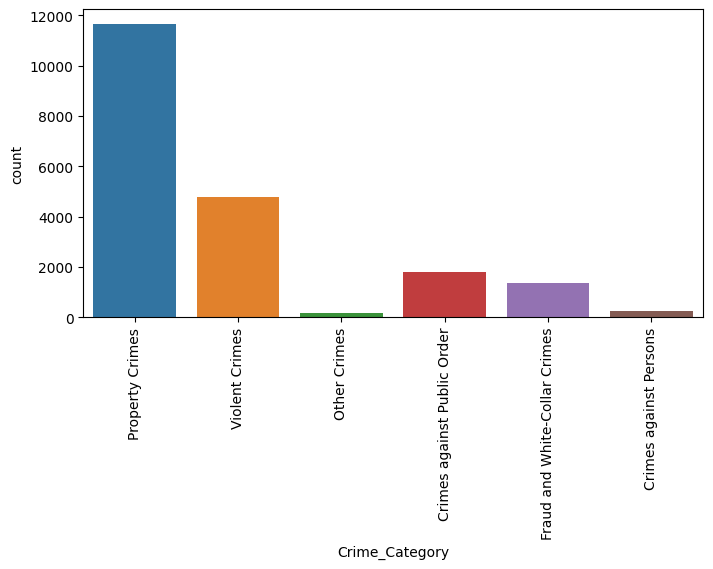

In [15]:
plt.figure(figsize= (8,4))
sns.countplot(data= train, x= train['Crime_Category'])
plt.xticks(rotation= 90)
plt.show()

**Insights**
- Target variable is highly skewed with "Property Crimes"

#### Numerical Features

**Univariate Analysis**

In [16]:
train["Latitude"].value_counts()

Latitude
34.2012    90
34.1867    86
34.1016    86
34.0980    85
34.1649    80
           ..
33.9316     1
34.1263     1
33.7287     1
34.2291     1
33.7173     1
Name: count, Length: 3622, dtype: int64

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


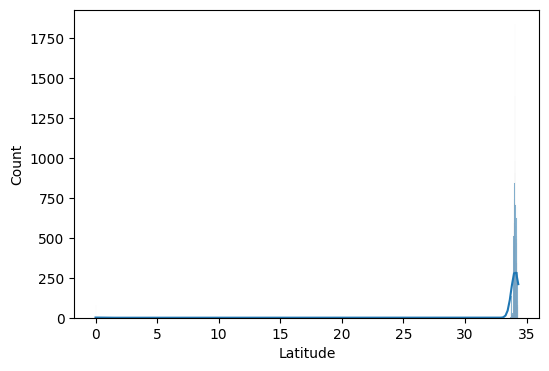

In [17]:
plt.figure(figsize= (6,4))
sns.histplot(data= train["Latitude"], kde='True')
plt.show()

**Insights**
- Latitude feature is right skewed around "34"

In [18]:
train["Longitude"].value_counts()

Longitude
-118.2739    168
-118.2827    139
-118.2915     88
-118.2652     87
-118.3089     86
            ... 
-118.2158      1
-118.4969      1
-118.2350      1
-118.5550      1
-118.5285      1
Name: count, Length: 3578, dtype: int64

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


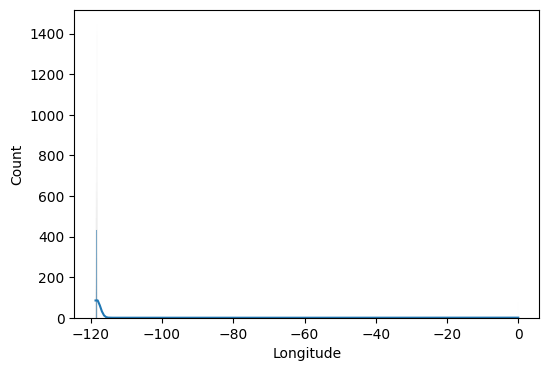

In [19]:
plt.figure(figsize= (6,4))
sns.histplot(data= train["Longitude"], kde='True')
plt.show()

**Insights**
- Longitude feature is left skewed around "-118"

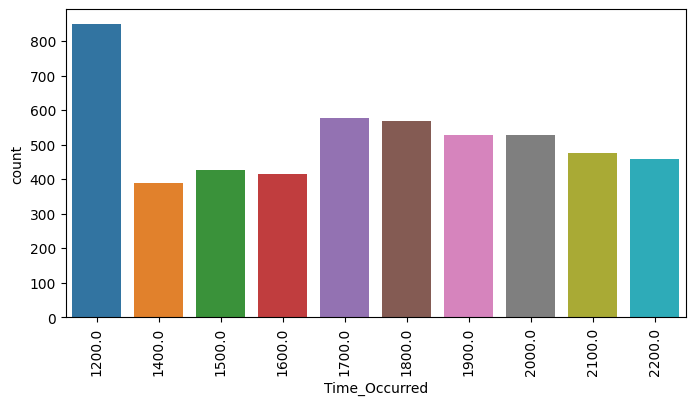

In [20]:
plt.figure(figsize= (8,4))
values = train['Time_Occurred'].value_counts().head(10)
sns.barplot(x= values.index, y= values)
plt.xticks(rotation= 90)
plt.show()

**Insights**
- Most of the crimes happened around "12 PM"

In [21]:
train["Victim_Age"].value_counts().head(20)

Victim_Age
0.0     4828
30.0     448
31.0     446
26.0     442
29.0     425
25.0     413
35.0     411
32.0     405
27.0     397
28.0     396
34.0     395
33.0     387
36.0     361
24.0     358
37.0     350
19.0     344
38.0     332
23.0     332
40.0     311
39.0     310
Name: count, dtype: int64

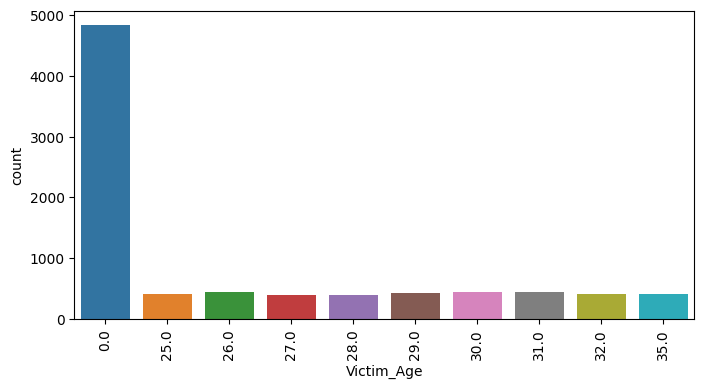

In [22]:
plt.figure(figsize= (8,4))
values = train['Victim_Age'].value_counts().head(10)
sns.barplot(x= values.index, y= values)
plt.xticks(rotation= 90)
plt.show()

**Insights**
- Most of the Victim_Age feature has value of "0"

**Bivariate Analysis**

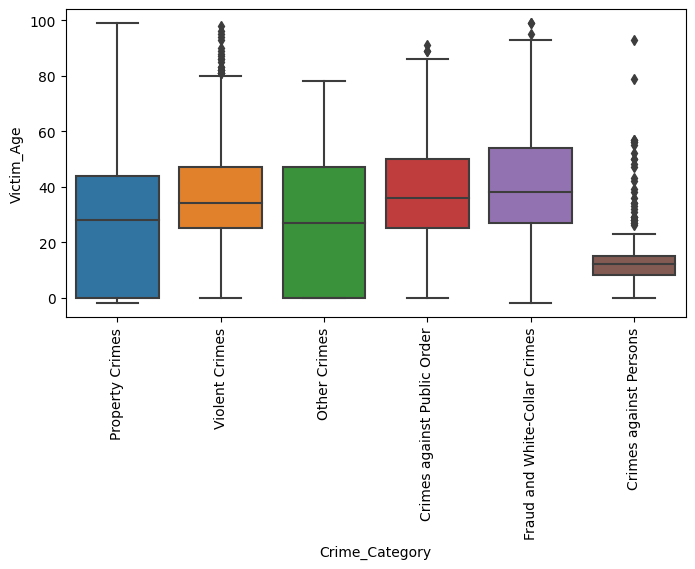

In [23]:
plt.figure(figsize= (8,4))
sns.boxplot(data= train, x= train["Crime_Category"], y= train["Victim_Age"])
plt.xticks(rotation= 90)
plt.show()

**Multivariate Analysis**

In [24]:
num_cols = train.select_dtypes(include= 'float64')
num_cols

,Latitude,Longitude,Time_Occurred,Area_ID,Reporting_District_no,Part 1-2,Victim_Age,Premise_Code,Weapon_Used_Code
0,34.1522,-118.3910,1800.0,15.0,1563.0,1.0,75.0,101.0,NaN
1,34.0028,-118.2391,1345.0,13.0,1367.0,1.0,41.0,216.0,400.0
2,34.0111,-118.2653,605.0,13.0,1343.0,2.0,67.0,501.0,NaN
3,34.2953,-118.4590,1800.0,19.0,1924.0,1.0,61.0,101.0,NaN
4,33.9787,-118.2918,1130.0,12.0,1245.0,1.0,0.0,401.0,400.0
...,...,...,...,...,...,...,...,...,...
19995,34.0334,-118.3523,700.0,3.0,303.0,2.0,51.0,501.0,400.0
19996,34.2212,-118.5011,259.0,10.0,1008.0,1.0,0.0,301.0,NaN
19997,34.0571,-118.3815,1400.0,8.0,849.0,1.0,42.0,102.0,NaN
19998,33.7451,-118.2835,600.0,5.0,558.0,2.0,76.0,501.0,NaN


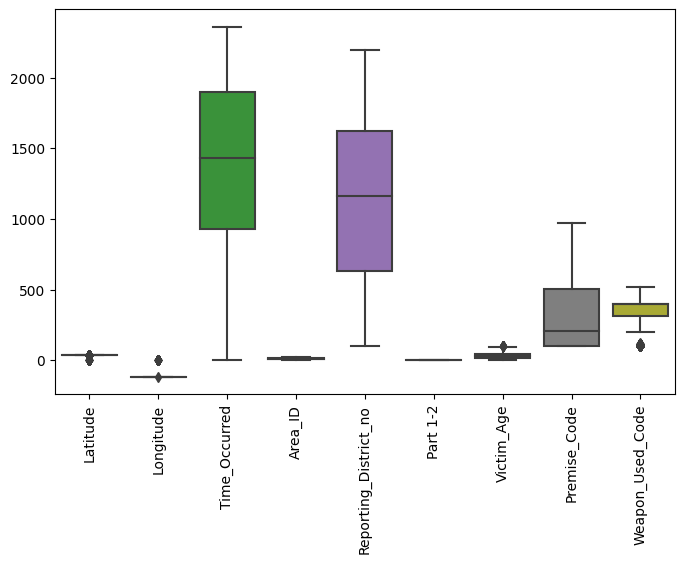

In [25]:
plt.figure(figsize= (8,5))
sns.boxplot(data= num_cols)
plt.xticks(rotation= 90)
plt.show()

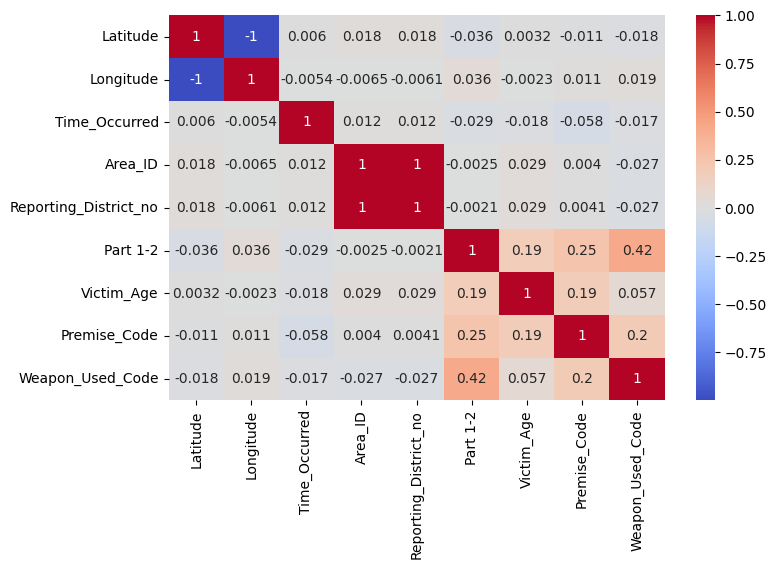

In [26]:
plt.figure(figsize=(8,5))
sns.heatmap(data= num_cols.corr(), annot=True, cmap= 'coolwarm')
plt.show()

**Insights**
- Reporting_District_no, Area_ID are perfectly positively correlated (1)
- Weapon_Used_Code, Part 1-2 features have medium postive correlation (0.42)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

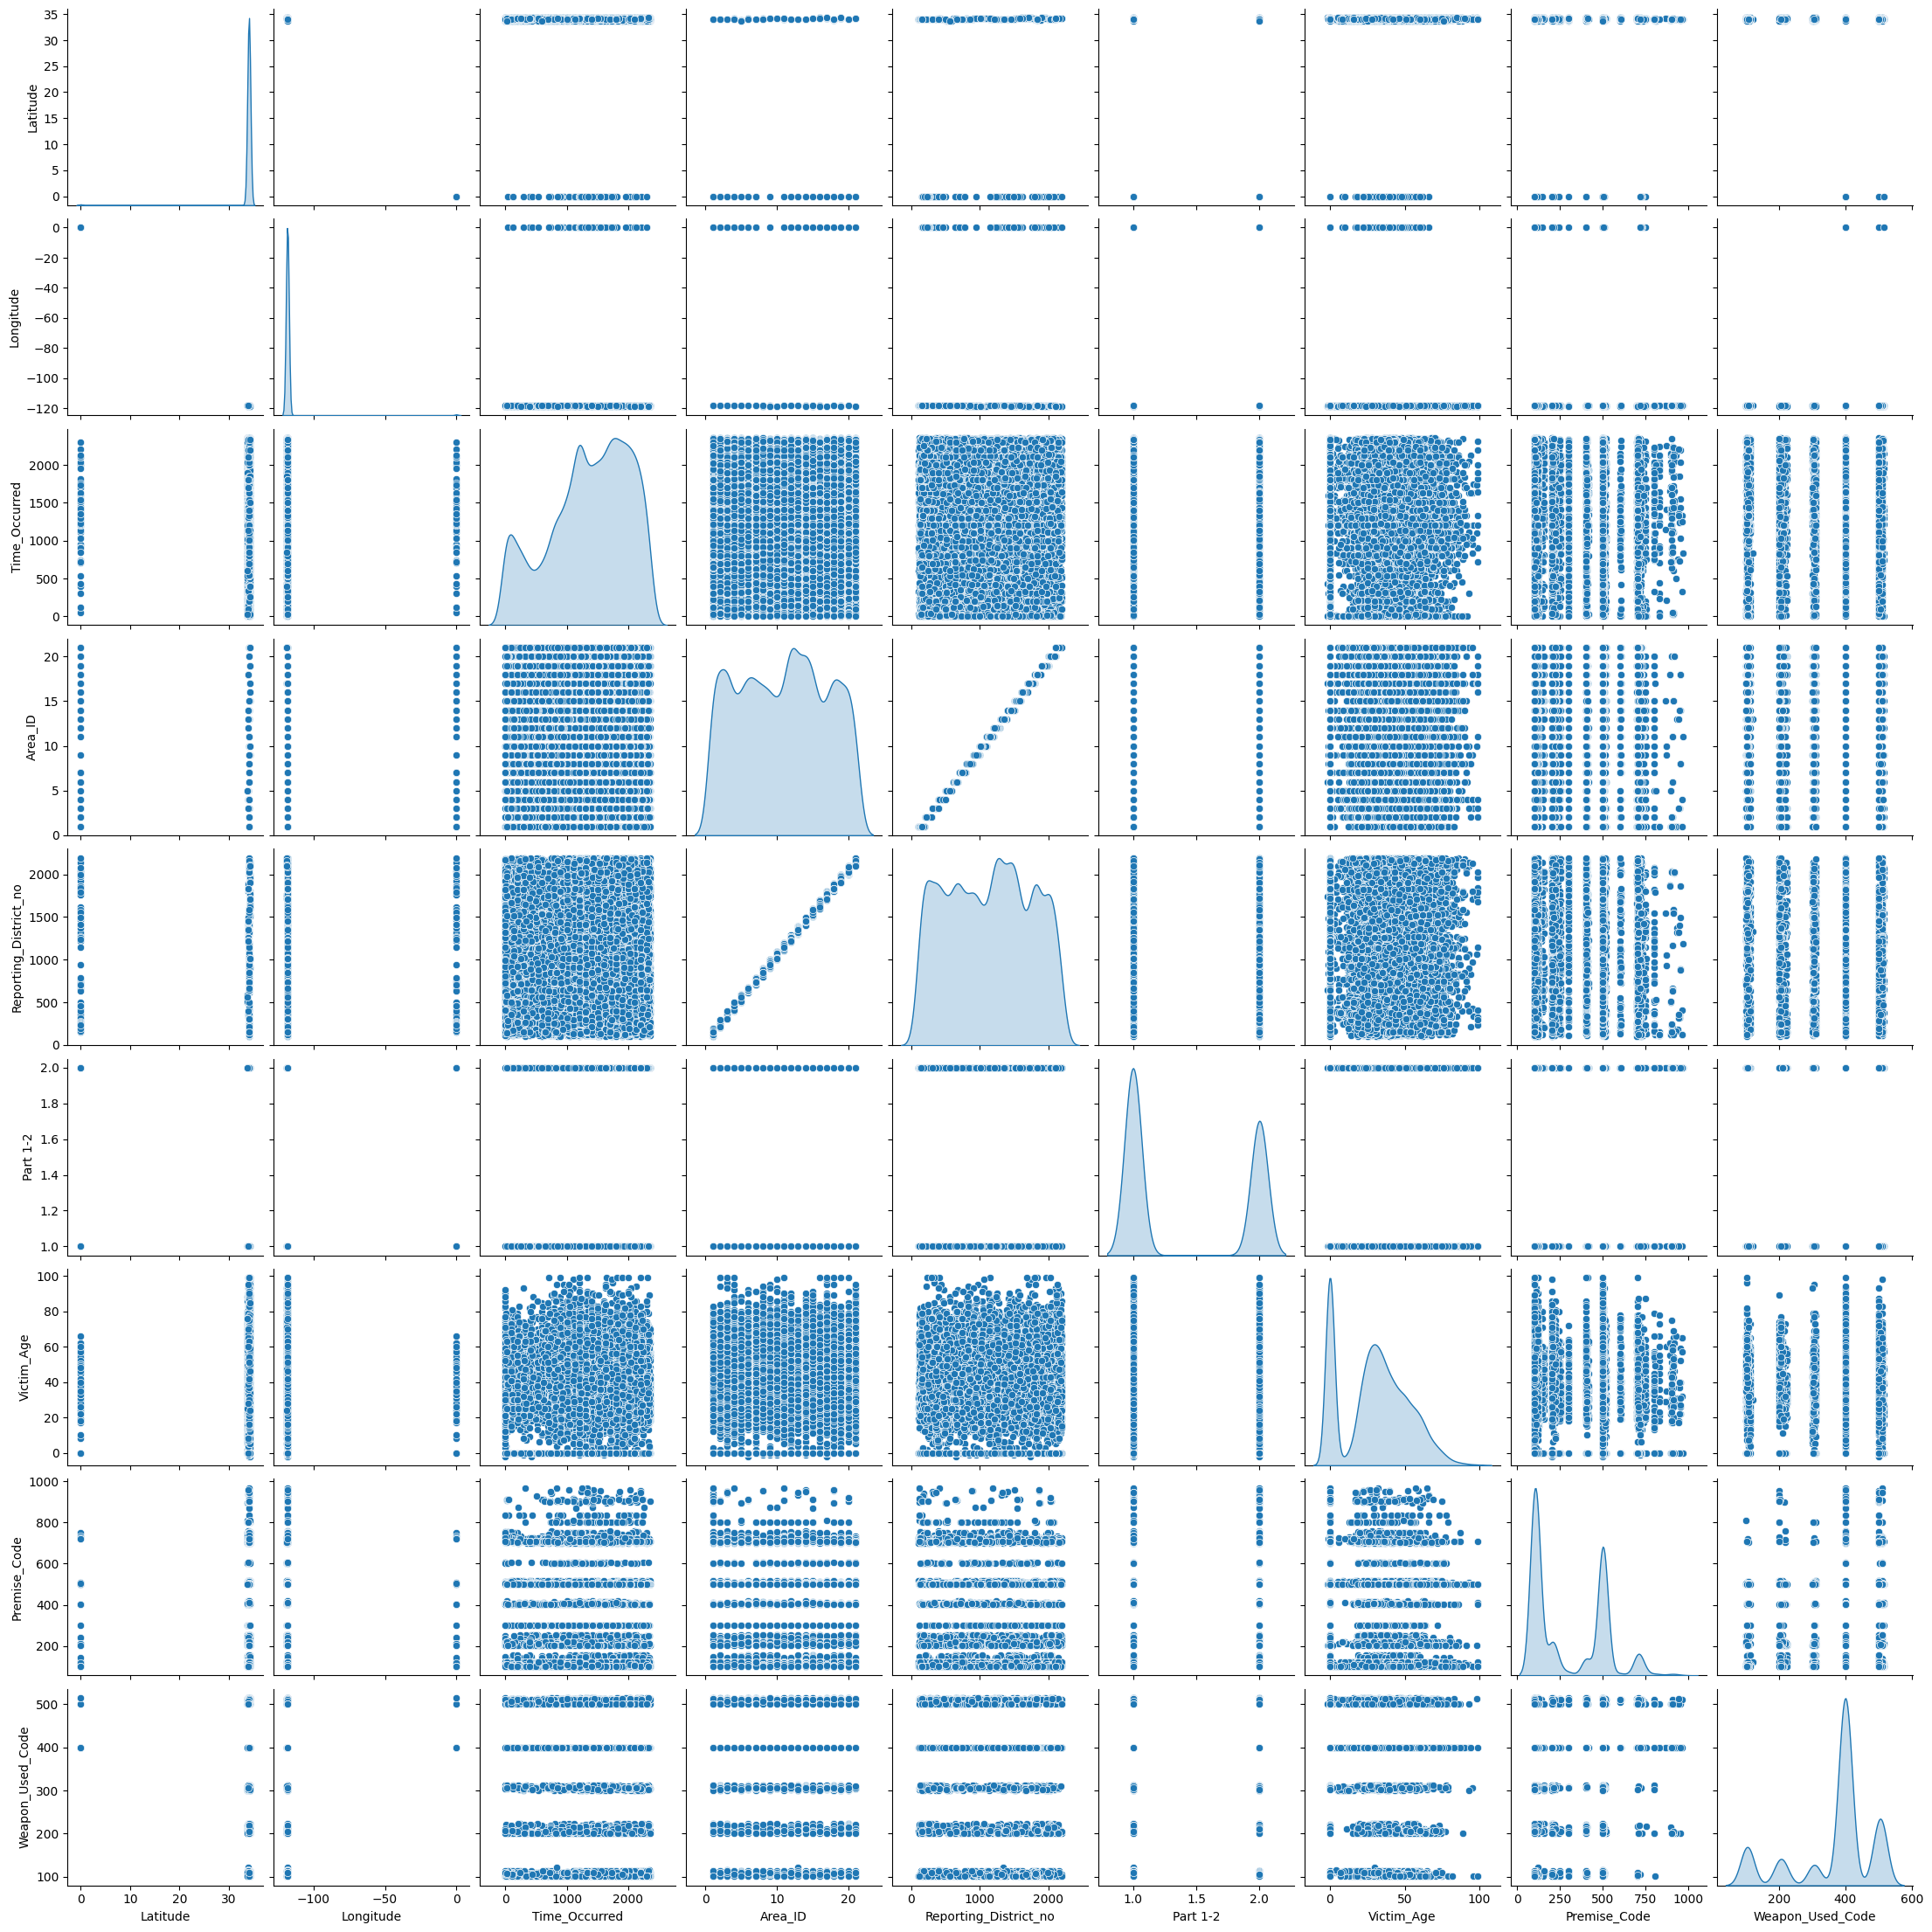

In [27]:
sns.pairplot(data= num_cols, diag_kind= 'kde')
plt.show()

#### Categorical Features

**Univariate Analysis**

In [28]:
train.columns

Index(['Location', 'Cross_Street', 'Latitude', 'Longitude', 'Date_Reported',
       'Date_Occurred', 'Time_Occurred', 'Area_ID', 'Area_Name',
       'Reporting_District_no', 'Part 1-2', 'Modus_Operandi', 'Victim_Age',
       'Victim_Sex', 'Victim_Descent', 'Premise_Code', 'Premise_Description',
       'Weapon_Used_Code', 'Weapon_Description', 'Status',
       'Status_Description', 'Crime_Category'],
      dtype='object')

In [29]:
train["Location"].value_counts()

Location
6TH                                        33
7TH                                        32
VERMONT                      AV            31
6TH                          ST            31
7TH                          ST            30
                                           ..
2700 E  1ST                          ST     1
9300    SWINTON                      AV     1
MCKINLEY                                    1
WADE                         ST             1
DALTON                       AV             1
Name: count, Length: 12399, dtype: int64

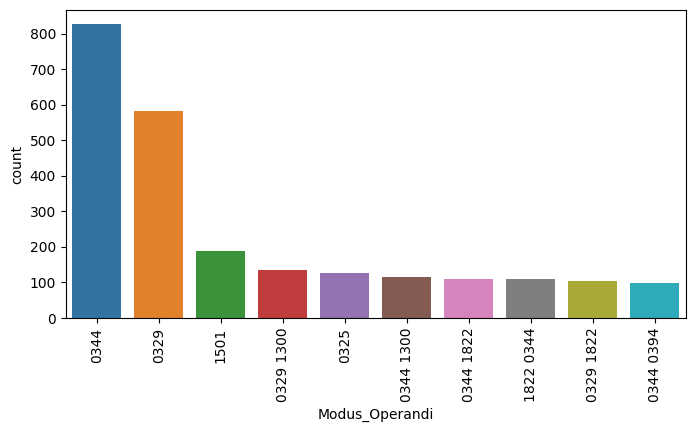

In [30]:
plt.figure(figsize= (8,4))
values = train['Modus_Operandi'].value_counts().head(10)
sns.barplot(x= values.index, y= values)
plt.xticks(rotation= 90)
plt.show()

**Insights**
- In Modus_Operandi feature, "0344" has the highest frequency

In [31]:
train["Area_ID"].value_counts()

Area_ID
12.0    1345
14.0    1157
1.0     1156
3.0     1130
18.0    1067
15.0    1065
6.0     1014
13.0     999
20.0     960
7.0      943
2.0      931
8.0      910
9.0      902
5.0      872
19.0     870
11.0     839
21.0     792
10.0     790
17.0     769
4.0      755
16.0     734
Name: count, dtype: int64

In [32]:
train["Area_Name"].value_counts()

Area_Name
77th Street    1345
Pacific        1157
Central        1156
Southwest      1130
Southeast      1067
N Hollywood    1065
Hollywood      1014
Newton          999
Olympic         960
Wilshire        943
Rampart         931
West LA         910
Van Nuys        902
Harbor          872
Mission         870
Northeast       839
Topanga         792
West Valley     790
Devonshire      769
Hollenbeck      755
Foothill        734
Name: count, dtype: int64

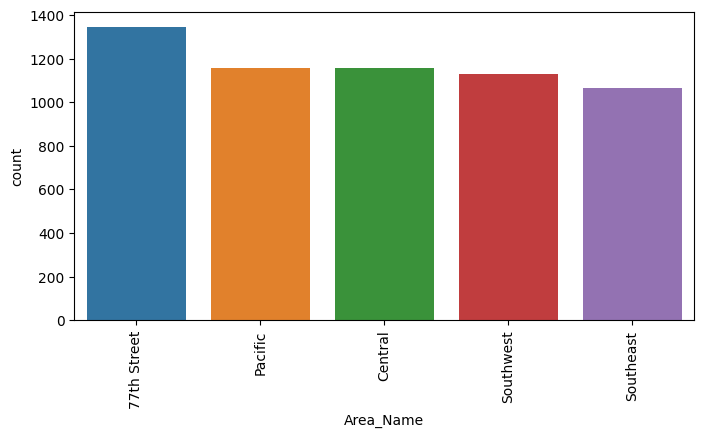

In [33]:
plt.figure(figsize= (8,4))
values = train['Area_Name'].value_counts().head()
sns.barplot(x= values.index, y= values)
plt.xticks(rotation= 90)
plt.show()

**Insights**
- Area_ID, Area_Name features are both indicating same thing

In [34]:
train["Premise_Code"].value_counts()

Premise_Code
101.0    5033
501.0    3379
502.0    2491
108.0    1437
102.0     978
         ... 
214.0       1
909.0       1
896.0       1
744.0       1
250.0       1
Name: count, Length: 217, dtype: int64

In [35]:
train["Premise_Description"].value_counts()

Premise_Description
STREET                                          5033
SINGLE FAMILY DWELLING                          3379
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    2491
PARKING LOT                                     1437
SIDEWALK                                         978
                                                ... 
BUS DEPOT/TERMINAL, OTHER THAN MTA                 1
MTA - RED LINE - HOLLYWOOD/WESTERN                 1
MTA - SILVER LINE - ROSECRANS                      1
HIGH-RISE BUILDING                                 1
COMPUTER SERVICES/REPAIRS/SALES                    1
Name: count, Length: 216, dtype: int64

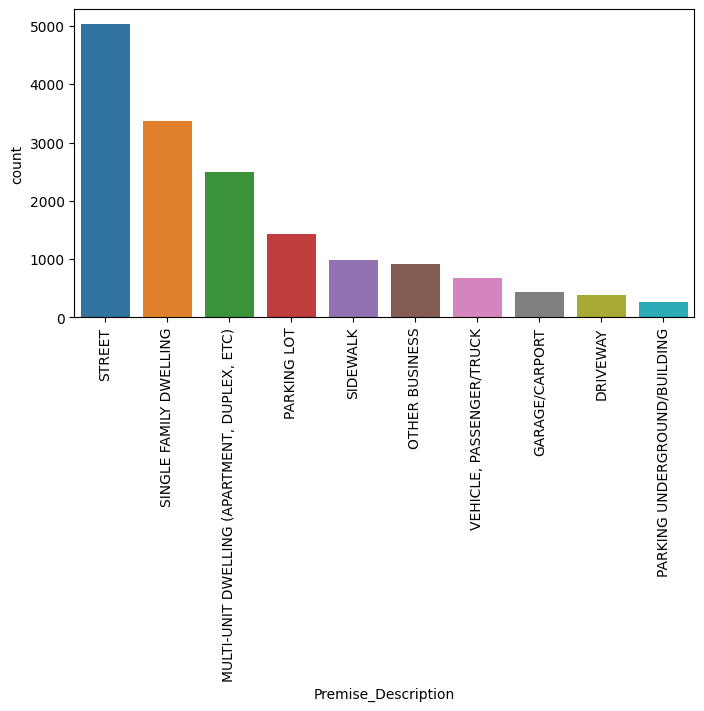

In [36]:
plt.figure(figsize= (8,4))
values = train['Premise_Description'].value_counts().head(10)
sns.barplot(x= values.index, y= values)
plt.xticks(rotation= 90)
plt.show()

**Insights**
- Premise_Code, Premise_Description features are both indicating same thing
- Premise_Code of "101.0" and Premise_Description of "STREET" has highest frequency

In [37]:
train["Weapon_Used_Code"].value_counts()

Weapon_Used_Code
400.0    3990
500.0     789
511.0     546
102.0     388
200.0     160
109.0     154
106.0     131
207.0     125
307.0      84
512.0      80
306.0      63
212.0      55
312.0      52
304.0      51
308.0      49
205.0      45
201.0      43
114.0      41
204.0      37
302.0      37
113.0      35
101.0      34
301.0      26
310.0      26
215.0      25
223.0      24
311.0      23
219.0      23
506.0      22
107.0      18
515.0      18
218.0      17
305.0      16
221.0      14
216.0      13
103.0      12
309.0      11
112.0       8
104.0       7
514.0       7
211.0       6
513.0       4
303.0       4
510.0       3
206.0       3
508.0       2
504.0       2
105.0       2
214.0       2
503.0       1
501.0       1
202.0       1
111.0       1
210.0       1
122.0       1
115.0       1
213.0       1
Name: count, dtype: int64

In [38]:
train["Status"].value_counts()

Status
IC    15236
AO     2597
AA     2054
JA       70
JO       43
Name: count, dtype: int64

In [39]:
train["Status_Description"].value_counts()

Status_Description
Invest Cont     15236
Adult Other      2597
Adult Arrest     2054
Juv Arrest         70
Juv Other          43
Name: count, dtype: int64

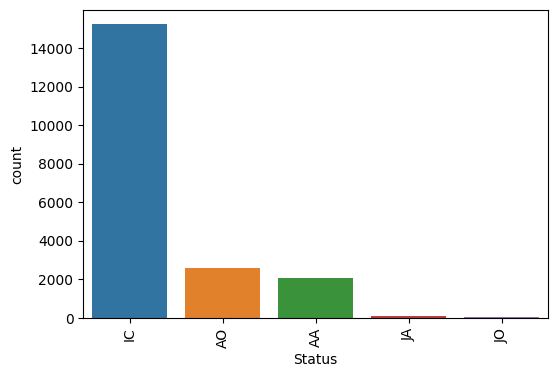

In [40]:
plt.figure(figsize= (6,4))
sns.countplot(data= train, x= train['Status'])
plt.xticks(rotation= 90)
plt.show()

**Insights**
- Status, Status_Description features are both indicating same thing
- Most of the crimes has status "IC"

#### Datetime Features

##### Train Data

In [41]:
train["Date_Reported"].unique()

array(['03/09/2020 12:00:00 AM', '02/27/2020 12:00:00 AM',
       '08/21/2020 12:00:00 AM', '11/08/2020 12:00:00 AM',
       '02/25/2020 12:00:00 AM', '01/10/2020 12:00:00 AM',
       '08/17/2020 12:00:00 AM', '10/07/2021 12:00:00 AM',
       '01/28/2020 12:00:00 AM', '07/07/2020 12:00:00 AM',
       '01/21/2020 12:00:00 AM', '06/11/2020 12:00:00 AM',
       '02/03/2020 12:00:00 AM', '02/22/2020 12:00:00 AM',
       '07/31/2020 12:00:00 AM', '09/08/2020 12:00:00 AM',
       '06/25/2020 12:00:00 AM', '09/11/2020 12:00:00 AM',
       '03/23/2020 12:00:00 AM', '02/12/2021 12:00:00 AM',
       '06/26/2020 12:00:00 AM', '07/26/2020 12:00:00 AM',
       '08/26/2020 12:00:00 AM', '10/29/2020 12:00:00 AM',
       '06/14/2020 12:00:00 AM', '12/27/2020 12:00:00 AM',
       '09/17/2020 12:00:00 AM', '06/19/2020 12:00:00 AM',
       '06/04/2020 12:00:00 AM', '02/06/2020 12:00:00 AM',
       '12/31/2020 12:00:00 AM', '01/22/2020 12:00:00 AM',
       '02/05/2020 12:00:00 AM', '10/21/2020 12:00:00 AM

In [42]:
# Date Occurred Feature

dt_occurred = pd.DataFrame()
dt_occurred["Date_Occurred"] = train["Date_Occurred"].copy()
dt_occurred["Date"] = pd.to_datetime(dt_occurred["Date_Occurred"])

dt_occurred["Occurred_Year"] = dt_occurred["Date"].dt.year
dt_occurred["Occurred_Month"] = dt_occurred["Date"].dt.month
dt_occurred["Occurred_DayofWeek"] = dt_occurred["Date"].dt.dayofweek


/tmp/ipykernel_33/1846314504.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_occurred["Date"] = pd.to_datetime(dt_occurred["Date_Occurred"])


In [43]:
dt_occurred = dt_occurred.drop(columns= ['Date_Occurred','Date'])

In [44]:
dt_occurred

,Occurred_Year,Occurred_Month,Occurred_DayofWeek
0,2020,3,4
1,2020,2,3
2,2020,8,4
3,2020,11,4
4,2020,2,1
...,...,...,...
19995,2020,5,6
19996,2020,12,4
19997,2020,9,4
19998,2020,6,2


In [45]:
dt_occurred["Occurred_Year"].value_counts()

Occurred_Year
2020    20000
Name: count, dtype: int64

In [46]:
dt_occurred["Occurred_Month"].value_counts()

Occurred_Month
1     1835
5     1755
6     1697
10    1685
7     1670
2     1663
8     1662
9     1643
12    1638
3     1630
4     1569
11    1553
Name: count, dtype: int64

In [47]:
dt_occurred["Occurred_DayofWeek"].value_counts()

Occurred_DayofWeek
4    3010
5    2932
2    2909
3    2881
1    2782
6    2751
0    2735
Name: count, dtype: int64

**Insights**
- All the crimes occurred in the year "2020"
- Highest no of crimes occurred on the month "January" and on day "Thursday"
- Least no of crimes occurred on the month "November" and on day "Saturday,Sunday"

In [48]:
# Date Reported Feature

dt_reported = pd.DataFrame()
dt_reported["Date_Reported"] = train["Date_Reported"].copy()
dt_reported["Date"] = pd.to_datetime(dt_reported["Date_Reported"])

dt_reported["Reported_Year"] = dt_reported["Date"].dt.year
dt_reported["Reported_Month"] = dt_reported["Date"].dt.month
dt_reported["Reported_DayofWeek"] = dt_reported["Date"].dt.dayofweek


/tmp/ipykernel_33/1720952451.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_reported["Date"] = pd.to_datetime(dt_reported["Date_Reported"])


In [49]:
dt_reported = dt_reported.drop(columns= ['Date_Reported','Date'])

In [50]:
dt_reported

,Reported_Year,Reported_Month,Reported_DayofWeek
0,2020,3,0
1,2020,2,3
2,2020,8,4
3,2020,11,6
4,2020,2,1
...,...,...,...
19995,2020,5,6
19996,2020,12,4
19997,2020,9,4
19998,2020,6,2


In [51]:
dt_reported["Reported_Year"].value_counts()

Reported_Year
2020    19177
2021      532
2022      176
2023      108
2024        7
Name: count, dtype: int64

In [52]:
dt_reported["Reported_Month"].value_counts()

Reported_Month
1     1824
5     1754
2     1726
6     1725
7     1690
10    1681
9     1663
8     1634
3     1625
12    1587
11    1549
4     1542
Name: count, dtype: int64

In [53]:
dt_reported["Reported_DayofWeek"].value_counts()

Reported_DayofWeek
0    3036
1    3023
2    3019
3    2946
4    2897
5    2599
6    2480
Name: count, dtype: int64

**Insights**
- Most of the crimes are reported in the year "2020"
- Highest no of crimes reported on the month "January" and on day "Sunday,Monday"
- Least no of crimes reported on the month "April" and on day "Friday,Saturday"


In [54]:
train = pd.concat([train, dt_occurred, dt_reported], axis=1)

In [55]:
train.drop(columns= ['Date_Reported', 'Date_Occurred'], inplace= True)

In [56]:
train.head()

,Location,Cross_Street,Latitude,Longitude,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,Part 1-2,Modus_Operandi,...,Weapon_Description,Status,Status_Description,Crime_Category,Occurred_Year,Occurred_Month,Occurred_DayofWeek,Reported_Year,Reported_Month,Reported_DayofWeek
0,4500 CARPENTER AV,NaN,34.1522,-118.3910,1800.0,15.0,N Hollywood,1563.0,1.0,0385,...,NaN,IC,Invest Cont,Property Crimes,2020,3,4,2020,3,0
1,45TH ST,ALAMEDA ST,34.0028,-118.2391,1345.0,13.0,Newton,1367.0,1.0,0906 0352 0371 0446 1822 0344 0416 0417,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes,2020,2,3,2020,2,3
2,600 E MARTIN LUTHER KING JR BL,NaN,34.0111,-118.2653,605.0,13.0,Newton,1343.0,2.0,0329 1202,...,NaN,IC,Invest Cont,Property Crimes,2020,8,4,2020,8,4
3,14900 ORO GRANDE ST,NaN,34.2953,-118.4590,1800.0,19.0,Mission,1924.0,1.0,0329 1300,...,NaN,IC,Invest Cont,Property Crimes,2020,11,4,2020,11,6
4,7100 S VERMONT AV,NaN,33.9787,-118.2918,1130.0,12.0,77th Street,1245.0,1.0,0416 0945 1822 0400 0417 0344,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,Property Crimes,2020,2,1,2020,2,1


##### Test Data

In [57]:
test["Date_Reported"].unique()

array(['03/03/2020 12:00:00 AM', '06/01/2020 12:00:00 AM',
       '08/28/2020 12:00:00 AM', '12/23/2020 12:00:00 AM',
       '08/30/2020 12:00:00 AM', '10/19/2020 12:00:00 AM',
       '09/26/2020 12:00:00 AM', '03/04/2020 12:00:00 AM',
       '10/24/2020 12:00:00 AM', '09/27/2020 12:00:00 AM',
       '08/12/2020 12:00:00 AM', '08/14/2020 12:00:00 AM',
       '02/14/2020 12:00:00 AM', '03/03/2021 12:00:00 AM',
       '07/03/2020 12:00:00 AM', '02/09/2020 12:00:00 AM',
       '07/24/2020 12:00:00 AM', '11/19/2020 12:00:00 AM',
       '01/29/2020 12:00:00 AM', '03/07/2020 12:00:00 AM',
       '07/16/2020 12:00:00 AM', '11/15/2020 12:00:00 AM',
       '02/25/2020 12:00:00 AM', '02/11/2020 12:00:00 AM',
       '04/26/2020 12:00:00 AM', '01/25/2022 12:00:00 AM',
       '04/14/2020 12:00:00 AM', '01/19/2020 12:00:00 AM',
       '06/29/2020 12:00:00 AM', '06/26/2020 12:00:00 AM',
       '09/06/2020 12:00:00 AM', '01/23/2020 12:00:00 AM',
       '09/21/2020 12:00:00 AM', '09/15/2020 12:00:00 AM

In [58]:
# Date Occurred Feature

dt_occurred_test = pd.DataFrame()
dt_occurred_test["Date_Occurred"] = test["Date_Occurred"].copy()
dt_occurred_test["Date"] = pd.to_datetime(dt_occurred_test["Date_Occurred"])

dt_occurred_test["Occurred_Year"] = dt_occurred_test["Date"].dt.year
dt_occurred_test["Occurred_Month"] = dt_occurred_test["Date"].dt.month
dt_occurred_test["Occurred_DayofWeek"] = dt_occurred_test["Date"].dt.dayofweek

/tmp/ipykernel_33/44891625.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_occurred_test["Date"] = pd.to_datetime(dt_occurred_test["Date_Occurred"])


In [59]:
dt_occurred_test

,Date_Occurred,Date,Occurred_Year,Occurred_Month,Occurred_DayofWeek
0,03/03/2020 12:00:00 AM,2020-03-03,2020,3,1
1,04/25/2020 12:00:00 AM,2020-04-25,2020,4,5
2,08/27/2020 12:00:00 AM,2020-08-27,2020,8,3
3,12/03/2020 12:00:00 AM,2020-12-03,2020,12,3
4,08/29/2020 12:00:00 AM,2020-08-29,2020,8,5
...,...,...,...,...,...
4995,06/04/2020 12:00:00 AM,2020-06-04,2020,6,3
4996,11/25/2020 12:00:00 AM,2020-11-25,2020,11,2
4997,11/21/2020 12:00:00 AM,2020-11-21,2020,11,5
4998,02/29/2020 12:00:00 AM,2020-02-29,2020,2,5


In [60]:
dt_occurred_test = dt_occurred_test.drop(columns= ['Date_Occurred','Date'])

In [61]:
dt_occurred_test

,Occurred_Year,Occurred_Month,Occurred_DayofWeek
0,2020,3,1
1,2020,4,5
2,2020,8,3
3,2020,12,3
4,2020,8,5
...,...,...,...
4995,2020,6,3
4996,2020,11,2
4997,2020,11,5
4998,2020,2,5


In [62]:
# Date Reported Feature

dt_reported_test = pd.DataFrame()
dt_reported_test["Date_Reported"] = test["Date_Reported"].copy()
dt_reported_test["Date"] = pd.to_datetime(dt_reported_test["Date_Reported"])

dt_reported_test["Reported_Year"] = dt_reported_test["Date"].dt.year
dt_reported_test["Reported_Month"] = dt_reported_test["Date"].dt.month
dt_reported_test["Reported_DayofWeek"] = dt_reported_test["Date"].dt.dayofweek


/tmp/ipykernel_33/1187864843.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_reported_test["Date"] = pd.to_datetime(dt_reported_test["Date_Reported"])


In [63]:
dt_reported_test

,Date_Reported,Date,Reported_Year,Reported_Month,Reported_DayofWeek
0,03/03/2020 12:00:00 AM,2020-03-03,2020,3,1
1,06/01/2020 12:00:00 AM,2020-06-01,2020,6,0
2,08/28/2020 12:00:00 AM,2020-08-28,2020,8,4
3,12/23/2020 12:00:00 AM,2020-12-23,2020,12,2
4,08/30/2020 12:00:00 AM,2020-08-30,2020,8,6
...,...,...,...,...,...
4995,06/05/2020 12:00:00 AM,2020-06-05,2020,6,4
4996,12/02/2020 12:00:00 AM,2020-12-02,2020,12,2
4997,11/21/2020 12:00:00 AM,2020-11-21,2020,11,5
4998,03/01/2020 12:00:00 AM,2020-03-01,2020,3,6


In [64]:
dt_reported_test = dt_reported_test.drop(columns= ['Date_Reported','Date'])

In [65]:
dt_reported_test

,Reported_Year,Reported_Month,Reported_DayofWeek
0,2020,3,1
1,2020,6,0
2,2020,8,4
3,2020,12,2
4,2020,8,6
...,...,...,...
4995,2020,6,4
4996,2020,12,2
4997,2020,11,5
4998,2020,3,6


In [66]:
test = pd.concat([test, dt_occurred_test, dt_reported_test], axis=1)

In [67]:
test.drop(columns= ['Date_Reported', 'Date_Occurred'], inplace= True)

In [68]:
test.head()

,Location,Cross_Street,Latitude,Longitude,Time_Occurred,Area_ID,Area_Name,Reporting_District_no,Part 1-2,Modus_Operandi,...,Weapon_Used_Code,Weapon_Description,Status,Status_Description,Occurred_Year,Occurred_Month,Occurred_DayofWeek,Reported_Year,Reported_Month,Reported_DayofWeek
0,1500 LEIGHTON AV,NaN,34.0128,-118.3045,2000.0,3.0,Southwest,376.0,2.0,0416 1241 1243 1813 1821 2000,...,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,2020,3,1,2020,3,1
1,100 S NORMANDIE AV,NaN,34.0726,-118.3029,1700.0,20.0,Olympic,2014.0,1.0,0344 0394,...,NaN,NaN,IC,Invest Cont,2020,4,5,2020,6,0
2,300 E 111TH ST,NaN,33.9348,-118.2695,900.0,18.0,Southeast,1844.0,2.0,1822 0701 1914 0355 1202 0100,...,NaN,NaN,IC,Invest Cont,2020,8,3,2020,8,4
3,1300 S LA BREA AV,NaN,34.0497,-118.3442,2200.0,7.0,Wilshire,765.0,1.0,NaN,...,NaN,NaN,IC,Invest Cont,2020,12,3,2020,12,2
4,11000 MORRISON ST,NaN,34.1611,-118.3704,130.0,15.0,N Hollywood,1555.0,2.0,1501,...,NaN,NaN,AO,Adult Other,2020,8,5,2020,8,6


# 4. Imputation

##### Train Data

In [69]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               20000 non-null  object 
 1   Cross_Street           3448 non-null   object 
 2   Latitude               20000 non-null  float64
 3   Longitude              20000 non-null  float64
 4   Time_Occurred          20000 non-null  float64
 5   Area_ID                20000 non-null  float64
 6   Area_Name              20000 non-null  object 
 7   Reporting_District_no  20000 non-null  float64
 8   Part 1-2               20000 non-null  float64
 9   Modus_Operandi         17259 non-null  object 
 10  Victim_Age             20000 non-null  float64
 11  Victim_Sex             17376 non-null  object 
 12  Victim_Descent         17376 non-null  object 
 13  Premise_Code           20000 non-null  float64
 14  Premise_Description    19995 non-null  object 
 15  We

In [70]:
train.isnull().sum()

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                   0
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
Crime_Category               0
Occurred_Year                0
Occurred_Month               0
Occurred_DayofWeek           0
Reported_Year                0
Reported_Month               0
Reported_DayofWeek           0
dtype: int64

In [71]:
(train["Victim_Age"].isin([-2,-1,0])).sum()

4834

In [72]:
train["Victim_Age"].replace([-2,-1,0], np.nan , inplace=True)    

/tmp/ipykernel_33/2542588771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Victim_Age"].replace([-2,-1,0], np.nan , inplace=True)


In [73]:
train.isnull().sum()

Location                     0
Cross_Street             16552
Latitude                     0
Longitude                    0
Time_Occurred                0
Area_ID                      0
Area_Name                    0
Reporting_District_no        0
Part 1-2                     0
Modus_Operandi            2741
Victim_Age                4834
Victim_Sex                2624
Victim_Descent            2624
Premise_Code                 0
Premise_Description          5
Weapon_Used_Code         12665
Weapon_Description       12665
Status                       0
Status_Description           0
Crime_Category               0
Occurred_Year                0
Occurred_Month               0
Occurred_DayofWeek           0
Reported_Year                0
Reported_Month               0
Reported_DayofWeek           0
dtype: int64

In [74]:
train.shape

(20000, 26)

In [75]:
(train.isnull().sum()/ train.shape[0])*100

Location                  0.000
Cross_Street             82.760
Latitude                  0.000
Longitude                 0.000
Time_Occurred             0.000
Area_ID                   0.000
Area_Name                 0.000
Reporting_District_no     0.000
Part 1-2                  0.000
Modus_Operandi           13.705
Victim_Age               24.170
Victim_Sex               13.120
Victim_Descent           13.120
Premise_Code              0.000
Premise_Description       0.025
Weapon_Used_Code         63.325
Weapon_Description       63.325
Status                    0.000
Status_Description        0.000
Crime_Category            0.000
Occurred_Year             0.000
Occurred_Month            0.000
Occurred_DayofWeek        0.000
Reported_Year             0.000
Reported_Month            0.000
Reported_DayofWeek        0.000
dtype: float64

**Insights**
- Features ( 'Cross_Street', 'Weapon_Used_Code', 'Weapon_Description' ) are having more that 50% null values

In [76]:
train = train.drop(columns= ['Cross_Street','Weapon_Used_Code','Weapon_Description' ])

In [77]:
train.isnull().sum()

Location                    0
Latitude                    0
Longitude                   0
Time_Occurred               0
Area_ID                     0
Area_Name                   0
Reporting_District_no       0
Part 1-2                    0
Modus_Operandi           2741
Victim_Age               4834
Victim_Sex               2624
Victim_Descent           2624
Premise_Code                0
Premise_Description         5
Status                      0
Status_Description          0
Crime_Category              0
Occurred_Year               0
Occurred_Month              0
Occurred_DayofWeek          0
Reported_Year               0
Reported_Month              0
Reported_DayofWeek          0
dtype: int64

In [78]:
median_imputer = SimpleImputer(strategy= "median")     # For numerical features
mode_imputer = SimpleImputer(strategy= "most_frequent")  # for categorical features

In [79]:
train["Victim_Age"] = pd.DataFrame(median_imputer.fit_transform(np.array(train["Victim_Age"]).reshape(-1,1)).astype("int64"), index= train.index, columns= ['Victim_Age'])

In [80]:
train.isnull().sum()

Location                    0
Latitude                    0
Longitude                   0
Time_Occurred               0
Area_ID                     0
Area_Name                   0
Reporting_District_no       0
Part 1-2                    0
Modus_Operandi           2741
Victim_Age                  0
Victim_Sex               2624
Victim_Descent           2624
Premise_Code                0
Premise_Description         5
Status                      0
Status_Description          0
Crime_Category              0
Occurred_Year               0
Occurred_Month              0
Occurred_DayofWeek          0
Reported_Year               0
Reported_Month              0
Reported_DayofWeek          0
dtype: int64

In [81]:
null_cols = ['Modus_Operandi', 'Victim_Sex', 'Victim_Descent', 'Premise_Description']
null_cols

['Modus_Operandi', 'Victim_Sex', 'Victim_Descent', 'Premise_Description']

In [82]:
train[null_cols] = pd.DataFrame(mode_imputer.fit_transform(train[null_cols]), index= train.index, columns= null_cols)

In [83]:
train.isnull().sum().sum()

0

##### Test Data

In [84]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Location               5000 non-null   object 
 1   Cross_Street           810 non-null    object 
 2   Latitude               5000 non-null   float64
 3   Longitude              5000 non-null   float64
 4   Time_Occurred          5000 non-null   float64
 5   Area_ID                5000 non-null   float64
 6   Area_Name              5000 non-null   object 
 7   Reporting_District_no  5000 non-null   float64
 8   Part 1-2               5000 non-null   float64
 9   Modus_Operandi         4316 non-null   object 
 10  Victim_Age             5000 non-null   float64
 11  Victim_Sex             4357 non-null   object 
 12  Victim_Descent         4357 non-null   object 
 13  Premise_Code           5000 non-null   float64
 14  Premise_Description    4999 non-null   object 
 15  Weap

In [85]:
test.isnull().sum()

Location                    0
Cross_Street             4190
Latitude                    0
Longitude                   0
Time_Occurred               0
Area_ID                     0
Area_Name                   0
Reporting_District_no       0
Part 1-2                    0
Modus_Operandi            684
Victim_Age                  0
Victim_Sex                643
Victim_Descent            643
Premise_Code                0
Premise_Description         1
Weapon_Used_Code         3153
Weapon_Description       3153
Status                      0
Status_Description          0
Occurred_Year               0
Occurred_Month              0
Occurred_DayofWeek          0
Reported_Year               0
Reported_Month              0
Reported_DayofWeek          0
dtype: int64

In [86]:
(test["Victim_Age"].isin([-2,-1,0])).sum()

1191

In [87]:
test["Victim_Age"].replace([-2,-1,0], np.nan , inplace=True)

/tmp/ipykernel_33/3605389675.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Victim_Age"].replace([-2,-1,0], np.nan , inplace=True)


In [88]:
(test["Victim_Age"].isin([-2,-1,0])).sum()

0

In [89]:
(test.isnull().sum()/ test.shape[0])*100

Location                  0.00
Cross_Street             83.80
Latitude                  0.00
Longitude                 0.00
Time_Occurred             0.00
Area_ID                   0.00
Area_Name                 0.00
Reporting_District_no     0.00
Part 1-2                  0.00
Modus_Operandi           13.68
Victim_Age               23.82
Victim_Sex               12.86
Victim_Descent           12.86
Premise_Code              0.00
Premise_Description       0.02
Weapon_Used_Code         63.06
Weapon_Description       63.06
Status                    0.00
Status_Description        0.00
Occurred_Year             0.00
Occurred_Month            0.00
Occurred_DayofWeek        0.00
Reported_Year             0.00
Reported_Month            0.00
Reported_DayofWeek        0.00
dtype: float64

**Insights**
- Features ( 'Cross_Street', 'Weapon_Used_Code', 'Weapon_Description' ) are having more that 50% null values

In [90]:
test = test.drop(columns= ['Cross_Street','Weapon_Used_Code','Weapon_Description' ])

In [91]:
test.isnull().sum()

Location                    0
Latitude                    0
Longitude                   0
Time_Occurred               0
Area_ID                     0
Area_Name                   0
Reporting_District_no       0
Part 1-2                    0
Modus_Operandi            684
Victim_Age               1191
Victim_Sex                643
Victim_Descent            643
Premise_Code                0
Premise_Description         1
Status                      0
Status_Description          0
Occurred_Year               0
Occurred_Month              0
Occurred_DayofWeek          0
Reported_Year               0
Reported_Month              0
Reported_DayofWeek          0
dtype: int64

In [92]:
test["Victim_Age"] = pd.DataFrame(median_imputer.fit_transform(np.array(test["Victim_Age"]).reshape(-1,1)).astype("int64"), index= test.index, columns= ['Victim_Age'])

In [93]:
test.isnull().sum()

Location                   0
Latitude                   0
Longitude                  0
Time_Occurred              0
Area_ID                    0
Area_Name                  0
Reporting_District_no      0
Part 1-2                   0
Modus_Operandi           684
Victim_Age                 0
Victim_Sex               643
Victim_Descent           643
Premise_Code               0
Premise_Description        1
Status                     0
Status_Description         0
Occurred_Year              0
Occurred_Month             0
Occurred_DayofWeek         0
Reported_Year              0
Reported_Month             0
Reported_DayofWeek         0
dtype: int64

In [94]:
test[null_cols] = pd.DataFrame(mode_imputer.fit_transform(test[null_cols]), index= test.index, columns= null_cols)

In [95]:
test.isnull().sum().sum()

0

# 5. Splitting Data

#### Splitting training data into X,y

In [96]:
X = train.drop(columns = "Crime_Category")
y = train["Crime_Category"]

#### Splitting the training dataset into training and validation sets

In [97]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [98]:
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((16000, 22), (4000, 22), (16000,), (4000,))

# 6. Preprocessing

- Encoding catagorical, textual features into numerical columns
- Scaling numerical features

In [99]:
X_train.columns

Index(['Location', 'Latitude', 'Longitude', 'Time_Occurred', 'Area_ID',
       'Area_Name', 'Reporting_District_no', 'Part 1-2', 'Modus_Operandi',
       'Victim_Age', 'Victim_Sex', 'Victim_Descent', 'Premise_Code',
       'Premise_Description', 'Status', 'Status_Description', 'Occurred_Year',
       'Occurred_Month', 'Occurred_DayofWeek', 'Reported_Year',
       'Reported_Month', 'Reported_DayofWeek'],
      dtype='object')

In [100]:
# Numerical Columns
num_cols = ['Latitude', 'Longitude', 'Time_Occurred', 'Victim_Age']                

# Categorical Columns
cat_cols = ['Area_ID', 'Reporting_District_no', 'Part 1-2', 'Victim_Sex', 'Victim_Descent',
            'Premise_Code', 'Status', 'Occurred_Year','Occurred_Month', 'Occurred_DayofWeek',
            'Reported_Year','Reported_Month', 'Reported_DayofWeek']

# Textual Columns
text_cols = ['Location', 'Modus_Operandi']

**Insights**
- Features ( 'Area_Name', 'Premise_Description', 'Status_Description' ) are not taken for preprocessing since they are redundant features.

In [101]:
# Pipeline for scaling numerical features
num_pipeline = Pipeline([('std_scaler', StandardScaler())]) 


# Pipeline for encoding categorical features
cat_pipeline = Pipeline([('onehot', OneHotEncoder(handle_unknown= 'ignore'))]) 


# Pipeline for vectorizing textual features
text_pipeline = Pipeline([('tfidf', TfidfVectorizer())])     

In [102]:
# Column Transformer for preprocessing numerical and categorical features

Transformer1 = ColumnTransformer([('num', num_pipeline, num_cols),
                                  ('cat', cat_pipeline, cat_cols)])  


# Column Transformer for preprocessing textual features

Transformer2 = ColumnTransformer([('text1', text_pipeline, 'Location'),
                                  ('text2', text_pipeline, 'Modus_Operandi')])   


In [103]:
# Applying FeatureUnion for both column transformers

union = FeatureUnion([('trans1', Transformer1),
                      ('trans2', Transformer2)])

In [104]:
union

FeatureUnion(transformer_list=[('trans1',
                                ColumnTransformer(transformers=[('num',
                                                                 Pipeline(steps=[('std_scaler',
                                                                                  StandardScaler())]),
                                                                 ['Latitude',
                                                                  'Longitude',
                                                                  'Time_Occurred',
                                                                  'Victim_Age']),
                                                                ('cat',
                                                                 Pipeline(steps=[('onehot',
                                                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                                                 ['Area_ID',
                                                                  'Reporting_District_no',
                                                                  'Part 1-2',
                                                                  'Victim_Sex',
                                                                  'Victim_Descent',
                                                                  'Premise_Code',
                                                                  'Status',
                                                                  'Occurred_Year',
                                                                  'Occurred_Month',
                                                                  'Occurred_DayofWeek',
                                                                  'Reported_Year',
                                                                  'Reported_Month',
                                                                  'Reported_DayofWeek'])])),
                               ('trans2',
                                ColumnTransformer(transformers=[('text1',
                                                                 Pipeline(steps=[('tfidf',
                                                                                  TfidfVectorizer())]),
                                                                 'Location'),
                                                                ('text2',
                                                                 Pipeline(steps=[('tfidf',
                                                                                  TfidfVectorizer())]),
                                                                 'Modus_Operandi')]))])

In [105]:
X_train_transformed = union.fit_transform(X_train)
X_train_transformed                                          # Transformed X_train after preprocessing

<16000x4719 sparse matrix of type '<class 'numpy.float64'>'
	with 369457 stored elements in Compressed Sparse Row format>

In [106]:
X_valid_transformed = union.transform(X_valid)
X_valid_transformed                                          # Transformed X_valid after preprocessing

<4000x4719 sparse matrix of type '<class 'numpy.float64'>'
	with 92214 stored elements in Compressed Sparse Row format>

**Insights**
- After preprocessing, no of features increased from '22' to '4719'

# 7. Feature Engineering

### SelectKBest

- Applying Labelencoder to y_train, y_valid

In [107]:
label_en = LabelEncoder()
label_en

LabelEncoder()

In [108]:
y_train_encoded = label_en.fit_transform(y_train)       # Encoded y_train 
y_valid_encoded = label_en.transform(y_valid)           # Encoded y_valid

In [109]:
# Feature Selection - SelectKBest

skb = SelectKBest(score_func= f_regression, k= 1000)       
skb

SelectKBest(k=1000, score_func=<function f_regression at 0x7f1ce349c4c0>)

# 8. Models

In [110]:
svm = SVC(random_state = 42)
svm

SVC(random_state=42)

In [111]:
decision = DecisionTreeClassifier(random_state= 42)
decision

DecisionTreeClassifier(random_state=42)

In [112]:
random_forest = RandomForestClassifier(random_state = 42)
random_forest

RandomForestClassifier(random_state=42)

In [113]:
bagging = BaggingClassifier(estimator= decision, random_state= 42)
bagging

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  random_state=42)

In [114]:
grad_boost = GradientBoostingClassifier(random_state= 42)
grad_boost

GradientBoostingClassifier(random_state=42)

In [115]:
xgb = XGBClassifier(random_state= 42)
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [116]:
mlp = MLPClassifier(random_state= 42, max_iter= 1000)
mlp

MLPClassifier(max_iter=1000, random_state=42)

In [117]:
lgb = LGBMClassifier(random_state= 42)
lgb

LGBMClassifier(random_state=42)

# 9. Model Pipeline and Evaluation

### 1. XGB Classifier

In [118]:
# Pipeline for preprocessing, feature section and model
xgb_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', xgb)])

# Fitting on train data
xgb_pipeline.fit(X_train, y_train_encoded)    

# Predicting valid data
y_pred_xgb = xgb_pipeline.predict(X_valid)      

# Accuracy score
xgb_acc = accuracy_score(y_valid_encoded, y_pred_xgb)
print(f'XGBClassfier accuary: {xgb_acc}')

XGBClassfier accuary: 0.9435


### 2. LGBM Classifier

In [119]:
# Pipeline for preprocessing, feature section and model
lgb_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', lgb)])

# Fitting on train data
lgb_pipeline.fit(X_train, y_train_encoded)

# Predicting valid data
y_pred_lgb = lgb_pipeline.predict(X_valid)

# Accuracy score
lgb_acc = accuracy_score(y_valid_encoded, y_pred_lgb)
print(f'-------------\nLGBMClassfier accuary: {lgb_acc}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12431
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 337
[LightGBM] [Info] Start training from score -4.417654
[LightGBM] [Info] Start training from score -2.412121
[LightGBM] [Info] Start training from score -2.688248
[LightGBM] [Info] Start training from score -4.710531
[LightGBM] [Info] Start training from score -0.535823
[LightGBM] [Info] Start training from score -1.443394
-------------
LGBMClassfier accuary: 0.94325


### 3. SVM

In [120]:
# Pipeline for preprocessing, feature section and model
svm_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', svm)])

# Fitting on train data
svm_pipeline.fit(X_train, y_train_encoded)

# Predicting valid data
y_pred_svm = svm_pipeline.predict(X_valid)

# Accuracy score
svm_acc = accuracy_score(y_valid_encoded, y_pred_svm)
print(f'SVM accuary: {svm_acc}')

SVM accuary: 0.93175


### 4. Gradient Boosting

In [121]:
# Pipeline for preprocessing, feature section and model
grad_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', grad_boost)])

# Fitting on train data
grad_pipeline.fit(X_train, y_train_encoded)

# Predicting valid data
y_pred_grad = grad_pipeline.predict(X_valid)

# Accuracy score
grad_acc = accuracy_score(y_valid_encoded, y_pred_grad)
print(f'GradientBoost accuary: {grad_acc}')

GradientBoost accuary: 0.93275


### 5. Random Forest Classifier

In [122]:
# Pipeline for preprocessing, feature section and model
rf_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', random_forest)])

# Fitting on train data
rf_pipeline.fit(X_train, y_train_encoded)

# Predicting valid data
y_pred_rf = rf_pipeline.predict(X_valid)

# Accuracy score
rf_acc = accuracy_score(y_valid_encoded, y_pred_rf)
print(f'RandomForest accuracy: {rf_acc}')

RandomForest accuracy: 0.9395


### 6. Bagging

In [123]:
# Pipeline for preprocessing, feature section and model
bag_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', bagging)])

# Fitting on train data
bag_pipeline.fit(X_train, y_train_encoded)

# Predicting valid data
y_pred_bag = bag_pipeline.predict(X_valid)

# Accuracy score
bag_acc = accuracy_score(y_valid_encoded, y_pred_bag)
print(f'Bagging accuracy: {bag_acc}')

Bagging accuracy: 0.93525


### 7. MLP Classifier

In [124]:
# Pipeline for preprocessing, feature section and model
mlp_pipeline = Pipeline([('preprocessing', union),
                         ('feature_selection', skb),
                         ('model', mlp)])

# Fitting on train data
mlp_pipeline.fit(X_train, y_train_encoded)

# Predicting valid data
y_pred_mlp = mlp_pipeline.predict(X_valid)

# Accuracy score
mlp_acc = accuracy_score(y_valid_encoded, y_pred_mlp)
print(f'MLPClassifier accuracy: {mlp_acc}')

MLPClassifier accuracy: 0.927


# 10. Model Performance Comparison

In [125]:
# List of all the models
models = ['XGB', 'LGBM', 'RandomForest', 'Bagging', 'GradientBoost', 'SVM', 'MLP']

# Accuracy scores of the respective models
accuracies = [xgb_acc, lgb_acc, rf_acc, bag_acc, grad_acc, svm_acc, mlp_acc]

#### Bar plot

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


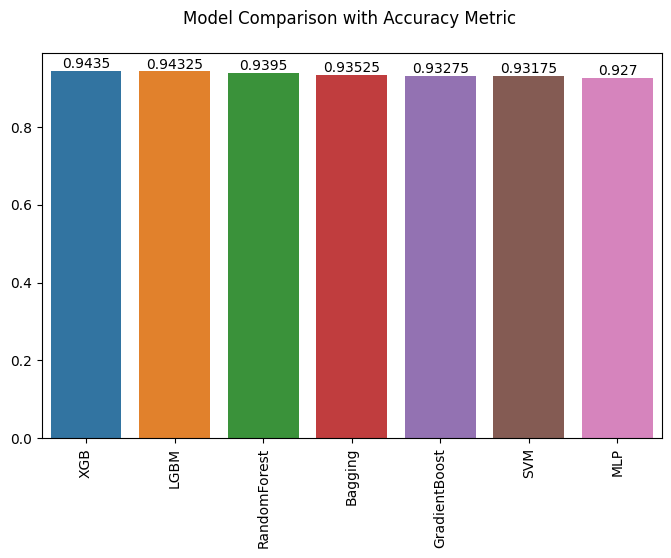

In [126]:
plt.figure(figsize= (8,5))
ax = sns.barplot(x= models, y= accuracies)
ax.bar_label(ax.containers[0])
plt.title("Model Comparison with Accuracy Metric \n")
plt.xticks(rotation= 90)
plt.show()

**Insights**
- In the above barplot,  "XGB Classifier", "LGBM Classifier", "Random Forest Classifier"  are the 3 top performing models in terms of accuracy.

## Evaluation Metrics for the Best 3 Models

In [127]:
# Target variable classes

labels = [" Crimes against Persons", "Crimes against Public Order", "Fraud and White-Collar Crimes", "Other Crimes", "Property Crimes", "Violent Crimes"]

### 1. XGB Classifier

#### Classification Report

In [128]:
print(classification_report(y_valid_encoded, y_pred_xgb,  target_names= labels))

                               precision    recall  f1-score   support

       Crimes against Persons       0.58      0.44      0.50        32
  Crimes against Public Order       0.82      0.83      0.82       374
Fraud and White-Collar Crimes       0.93      0.91      0.92       267
                 Other Crimes       0.31      0.14      0.20        35
              Property Crimes       0.99      0.99      0.99      2303
               Violent Crimes       0.92      0.94      0.93       989

                     accuracy                           0.94      4000
                    macro avg       0.76      0.71      0.73      4000
                 weighted avg       0.94      0.94      0.94      4000



#### Confusion Matrix

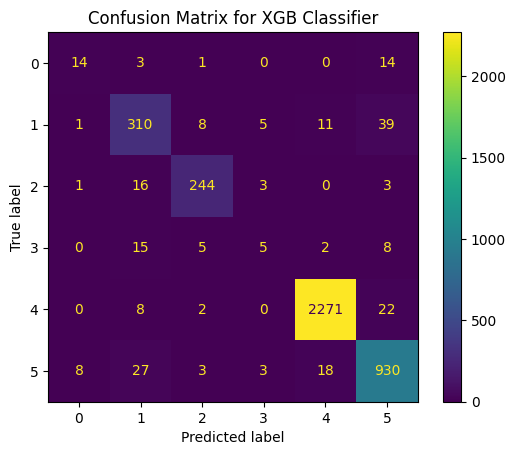

In [129]:
cmat_xgb = confusion_matrix(y_valid_encoded, y_pred_xgb)
cmat_disp_xgb = ConfusionMatrixDisplay(cmat_xgb)
cmat_disp_xgb.plot()
plt.title("Confusion Matrix for XGB Classifier")
plt.show()

## 2. LGBM Classifier

#### Classification Report

In [130]:
print(classification_report(y_valid_encoded, y_pred_lgb,  target_names= labels))

                               precision    recall  f1-score   support

       Crimes against Persons       0.57      0.38      0.45        32
  Crimes against Public Order       0.78      0.86      0.82       374
Fraud and White-Collar Crimes       0.95      0.89      0.92       267
                 Other Crimes       0.18      0.06      0.09        35
              Property Crimes       0.99      0.99      0.99      2303
               Violent Crimes       0.93      0.94      0.93       989

                     accuracy                           0.94      4000
                    macro avg       0.73      0.68      0.70      4000
                 weighted avg       0.94      0.94      0.94      4000



#### Confusion Matrix

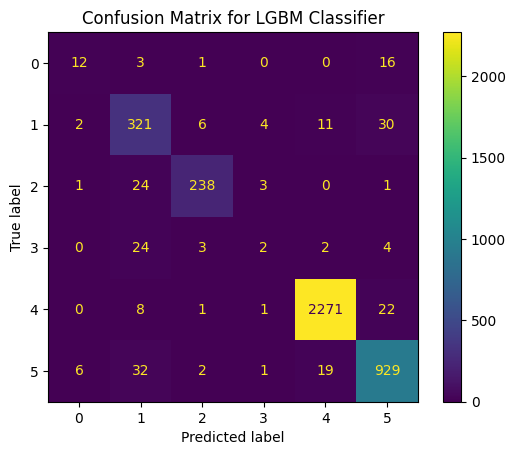

In [131]:
cmat_lgb = confusion_matrix(y_valid_encoded, y_pred_lgb)
cmat_disp_lgb = ConfusionMatrixDisplay(cmat_lgb)
cmat_disp_lgb.plot()
plt.title("Confusion Matrix for LGBM Classifier")
plt.show()

## 3. Random Forest Classifier

#### Classification Report

In [132]:
print(classification_report(y_valid_encoded, y_pred_rf,  target_names= labels))

                               precision    recall  f1-score   support

       Crimes against Persons       0.43      0.09      0.15        32
  Crimes against Public Order       0.82      0.77      0.80       374
Fraud and White-Collar Crimes       0.92      0.91      0.92       267
                 Other Crimes       0.60      0.09      0.15        35
              Property Crimes       0.98      0.99      0.99      2303
               Violent Crimes       0.89      0.96      0.92       989

                     accuracy                           0.94      4000
                    macro avg       0.77      0.63      0.65      4000
                 weighted avg       0.93      0.94      0.93      4000



#### Confusion Matrix

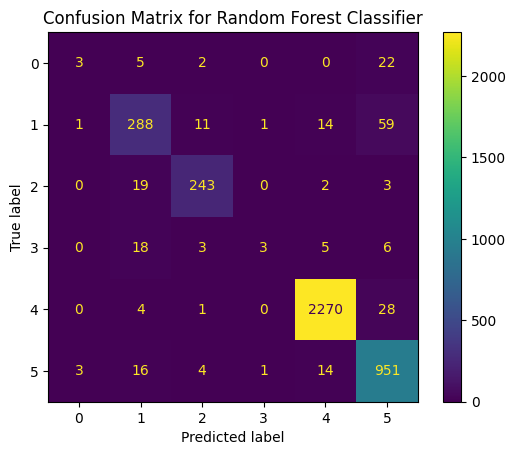

In [133]:
cmat_rf = confusion_matrix(y_valid_encoded, y_pred_rf)
cmat_disp_rf = ConfusionMatrixDisplay(cmat_rf)
cmat_disp_rf.plot()
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

### Accuracy and Macro Average Insights
- **Overall Accuracy** - All the models are having similar accuracy
- **Macro Average** - "XGBoostClassifier" slightly outperforms "LGBMClassifier" and "RandomForestClassifier", indiacating overall balance across all classes

### Class-Wise Performance
- **Crimes against Persons** - "XGBoost" and "LightGBM" perform similarly with "XGBoost" slightly ahead, "Random Forest" struggles significantly with this class

- **Crimes against Public Order** - All models perform similarly, but "LightGBM" showing higher recall but lower precision than "XGBoost"

- **Fraud and White-Collar Crimes** - All the three models perform almost equally well 

- **Other Crimes** - This class is challenging for all models. "XGBoost" has slightly better recall, while "Random Forest" has higher precision but struggles with recall

- **Property Crimes** - All models perform excellently in this class, with almost perfect precision, recall and F1-scores

- **Violent Crimes** - "XGBoost" and "LightGBM" perform very similarly, with "Random Forest" having slightly lower precision but higher recall

### Confusion Matrix Insights
- "XGBoost" and "LightGBM" classifiers show similar confusion matrices, with both handling the majority classes wee but struggling with the minority classes like "Other Crimes"

- "Random Forest" has a noticeably worse performance in classes like "Crimes against Persons" and "Other Crimes"

### Overall Insights
- "XGBoostClassifier" performs slightly better than "LGBMClassifier" in terms of overall balance, especially with minority classes.

- "RandomForestClassifier" is competitive in terms of overall accuracy but struggles significantly with minority classes 

# 11. Hyperparameter Tuning

### Cross Validation

In [134]:
cv = KFold(n_splits= 5)
cv

KFold(n_splits=5, random_state=None, shuffle=False)

### Pipeline for Preprocessing and Feature Engineering

In [135]:
Transform = Pipeline([('preprocessing', union),
                      ('feature_selection', skb)])

In [136]:
X_train_trans = Transform.fit_transform(X_train, y_train_encoded)  # Transformed train data

In [137]:
X_valid_trans = Transform.transform(X_valid)     # Transformed validation data

In [138]:
X_train_trans

<16000x1000 sparse matrix of type '<class 'numpy.float64'>'
	with 220696 stored elements in Compressed Sparse Row format>

In [139]:
X_valid_trans

<4000x1000 sparse matrix of type '<class 'numpy.float64'>'
	with 55345 stored elements in Compressed Sparse Row format>

## HPT for Random Forest

### Applying GridSearchCV

In [140]:
# Parameter grid1

rf_params1 = {
              "n_estimators": [100, 200],
              "criterion": ['gini', 'entropy'],
              "max_depth": [None, 10, 20],
              "min_samples_split": [2, 5],
              "min_samples_leaf": [1, 2],
              "bootstrap": [True, False]
            }

In [141]:
# rf_grid_search1 = GridSearchCV(estimator= random_forest, param_grid= rf_params1, cv= cv, n_jobs=-1, verbose= 3 )
# rf_grid_search1.fit(X_train_trans, y_train_encoded)

In [142]:
# rf_grid_search1.best_params_

In [143]:
# rf_grid_search1.best_score_

In [144]:
# rf_grid_search1.best_estimator_

In [145]:
# rf_grid_search1.best_estimator_.score(X_valid_trans, y_valid_encoded)

In [146]:
# Parameter grid2
rf_params2 = {
              "n_estimators": [100, 110],
              "criterion": ['gini', 'log_loss'],
              "max_depth": [None, 30, 50, 100],
              "min_samples_split": [5, 7, 10],
              "bootstrap": [False]
            }

In [147]:
# rf_grid_search2 = GridSearchCV(estimator= random_forest, param_grid= rf_params2, cv= cv, n_jobs=-1, verbose= 3 )
# rf_grid_search2.fit(X_train_trans, y_train_encoded)

In [148]:
# rf_grid_search2.best_params_

In [149]:
# rf_grid_search2.best_score_

In [150]:
# rf_grid_search2.best_estimator_

In [151]:
# rf_grid_search2.best_estimator_.score(X_valid_trans, y_valid_encoded)

**Insights**
- After doing Hyperparameter Tuning with both parameter grids ( rf_params1, rf_params2 ), the best parameters obtained were same { 'bootstrap' : False, 'min_sample_split' : 5 }
- Best score obtained was '0.9412'

### Best Estimator after HPT 

In [152]:
rf_best_estimator = RandomForestClassifier(min_samples_split= 5, bootstrap= False, random_state= 42)
rf_best_estimator.fit(X_train_trans, y_train_encoded)

RandomForestClassifier(bootstrap=False, min_samples_split=5, random_state=42)

In [153]:
# validation score 
rf_best_estimator.score(X_valid_trans, y_valid_encoded)

0.94425

**Insights**
- Validation score of the best Random Forest Classifier after HPT was '0.94425'
- The validation score of the Random Forest Classifier without HPT was '0.9395'

## HPT for LGBM Classifier

### Applying GridSearchCV

In [154]:
# Parameter grid1

lgb_params1 = {
               "num_leaves": [31, 35],
               "max_depth": [-1, 30],
               "learning_rate": [0.01, 0.1],
               "n_estimators": [100, 200],
               "class_weight": ['balanced', None],
               "min_child_samples": [20, 30]
             }

In [155]:
# lgb_grid_search1 = GridSearchCV( estimator= lgb, param_grid= lgb_params1, cv= cv, n_jobs= -1, verbose= 3 )
# lgb_grid_search1.fit(X_train_trans, y_train_encoded)

In [156]:
# lgb_grid_search1.best_params_

In [157]:
# lgb_grid_search1.best_estimator_

In [158]:
# lgb_grid_search1.best_score_

In [159]:
# lgb_grid_search1.best_estimator_.score(X_valid_trans, y_valid_encoded)

**Insights**
- After doing Hyperparameter Tuning with the parameter grid "lgb_params1", the best parameters obtained were { 'max_depth' : 30, 'num_leaves' : 35 }
- Best score obtained was '0.946' 

In [160]:
# Parameter grid2

lgb_params2 = {
               "num_leaves": [35, 40, 50],
               "max_depth": [-1, 30, 40, 50],
               "learning_rate": [0.05, 0.1],
               "min_child_samples": [20, 30]
             }

In [161]:
# lgb_grid_search2 = GridSearchCV( estimator= lgb, param_grid= lgb_params2, cv= cv, n_jobs= -1, verbose= 3 )
# lgb_grid_search2.fit(X_train_trans, y_train_encoded)

In [162]:
# lgb_grid_search2.best_params_

In [163]:
# lgb_grid_search2.best_estimator_

In [164]:
# lgb_grid_search2.best_score_

In [165]:
#lgb_grid_search2.best_estimator_.score(X_valid_trans, y_valid_encoded)

**Insights**
- After doing Hyperparameter Tuning with the parameter grid "lgb_params2", the best parameters obtained were { 'learning_rate' : 0.05, 'num_leaves' : 35 }
- Best score obtained was '0.947' 

### Best Estimator after HPT

In [166]:
lgb_best_estimator = LGBMClassifier(learning_rate= 0.05, num_leaves= 35, random_state= 42)

In [167]:
lgb_best_estimator.fit(X_train_trans, y_train_encoded)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12431
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 337
[LightGBM] [Info] Start training from score -4.417654
[LightGBM] [Info] Start training from score -2.412121
[LightGBM] [Info] Start training from score -2.688248
[LightGBM] [Info] Start training from score -4.710531
[LightGBM] [Info] Start training from score -0.535823
[LightGBM] [Info] Start training from score -1.443394


LGBMClassifier(learning_rate=0.05, num_leaves=35, random_state=42)

In [168]:
# validation score
lgb_best_estimator.score(X_valid_trans, y_valid_encoded)

0.945

**Insights**
- Since 2nd gridcv is performing well, it is taken as best LGBM Classifier
- The validation score after HPT was '0.945'
- The validation score without HPT was '0.94325'

## HPT for XGBoost Classifier

### Applying GridSearchCV

In [169]:
# Parameter grid1

xgb_params1 = {
               "n_estimators": [100, 200],
               "learning_rate": [0.01, 0.05, 0.1],
               "max_depth": [3, 6, 9]
             }

In [170]:
# xgb_grid_search1 = GridSearchCV( estimator= xgb, param_grid= xgb_params1, cv= cv, n_jobs= -1, verbose= 3 )
# xgb_grid_search1.fit(X_train_trans, y_train_encoded)

In [171]:
# xgb_grid_search1.best_params_

In [172]:
# xgb_grid_search1.best_score_

In [173]:
# xgb_grid_search1.best_estimator_

In [174]:
# xgb_grid_search1.best_estimator_.score(X_valid_trans, y_valid_encoded)

**Insights**
- After doing Hyperparameter Tuning with the parameter grid "xgb_params1", the best parameters obtained were { 'max_depth' : 6, 'learning_rate' : 0.1, 'n_estimators' : 200 }
- Best score obtained was '0.948' 

In [175]:
# Parameter grid2

xgb_params2 = {
               "n_estimators": [200, 300, 400],
               "learning_rate": [0.05, 0.1, 0.2],
               "max_depth": [5, 6, 7, 8, 9, 10]
             }

In [176]:
# xgb_grid_search2 = GridSearchCV( estimator= xgb, param_grid= xgb_params2, cv= cv, n_jobs= -1, verbose= 3 )
# xgb_grid_search2.fit(X_train_trans, y_train_encoded)

In [177]:
# xgb_grid_search2.best_params_

In [178]:
# xgb_grid_search2.best_score_

In [179]:
# xgb_grid_search2.best_estimator_

In [180]:
# xgb_grid_search2.best_estimator_.score(X_valid_trans, y_valid_encoded)

**Insights**
- After doing Hyperparameter Tuning with the parameter grid "xgb_params2", the best parameters obtained were { 'max_depth' : 6, 'learning_rate' : 0.1, 'n_estimators' : 300 }
- Best score obtained was '0.949' 

### Best estimator after HPT

In [181]:
xgb_best_estimator = XGBClassifier(learning_rate= 0.1, max_depth= 6, n_estimators= 300)

In [182]:
xgb_best_estimator.fit(X_train_trans, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [183]:
# validation score
xgb_best_estimator.score(X_valid_trans, y_valid_encoded)

0.943

**Insights**
- The validation score before and after hyperparameter tuning is same.

## 11. Best Model

In [184]:
# Pipeline of preprocessing, feature selection and the best model 

best_model = Pipeline([('preprocessing', union),
                      ('feature_selection', SelectKBest(f_regression, k=3000)),
                      ('model', xgb_best_estimator)])
best_model

Pipeline(steps=[('preprocessing',
                 FeatureUnion(transformer_list=[('trans1',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('std_scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['Latitude',
                                                                                   'Longitude',
                                                                                   'Time_Occurred',
                                                                                   'Victim_Age']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('onehot',
                                                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                                                  ['Area_ID',
                                                                                   'Reporting_District_no',
                                                                                   'Part '
                                                                                   '1-2',
                                                                                   'Victim_Se...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

**Insights**
- The best estimator chosen was XGB Classifier with selectkbest as feature engineering method with k= 3000 along with preprocessing

### Fitting on Whole Data

In [185]:
y_encoded = label_en.transform(y)
y_encoded

array([4, 4, 4, ..., 4, 1, 4])

In [186]:
best_model.fit(X, y_encoded)

Pipeline(steps=[('preprocessing',
                 FeatureUnion(transformer_list=[('trans1',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('std_scaler',
                                                                                                   StandardScaler())]),
                                                                                  ['Latitude',
                                                                                   'Longitude',
                                                                                   'Time_Occurred',
                                                                                   'Victim_Age']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('onehot',
                                                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                                                  ['Area_ID',
                                                                                   'Reporting_District_no',
                                                                                   'Part '
                                                                                   '1-2',
                                                                                   'Victim_Se...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [187]:
# Predicting whole train data
y_pred_encoded = best_model.predict(X)

# Accuracy score of whole train data 
accuracy_score(y_encoded, y_pred_encoded)

0.98925

### Prediction

In [188]:
y_pred = best_model.predict(test)
y_pred

array([5, 4, 2, ..., 5, 5, 4])

In [189]:
# Inversing the encoding of y

y_pred = label_en.inverse_transform(y_pred)
y_pred

array(['Violent Crimes', 'Property Crimes',
       'Fraud and White-Collar Crimes', ..., 'Violent Crimes',
       'Violent Crimes', 'Property Crimes'], dtype=object)

# 12. Submission

#### Loading Sample data

In [190]:
sample = pd.read_csv("/kaggle/input/crime-cast-forecasting-crime-categories/sample.csv")
sample

,ID,Crime_Category,Unnamed: 2
0,1,Crimes against Persons,NaN
1,2,Crimes against Public Order,NaN
2,3,Other Crimes,NaN
3,4,Crimes against Public Order,NaN
4,5,Other Crimes,NaN
...,...,...,...
995,996,Fraud and White-Collar Crimes,NaN
996,997,Property Crimes,NaN
997,998,Violent Crimes,NaN
998,999,Property Crimes,NaN


### Creating "submission.csv" file

In [191]:
submission = pd.DataFrame({'ID': np.arange(1,5001), 
                           'Crime_Category': y_pred}
                         )

In [192]:
submission.to_csv('submission.csv', index=False)

In [193]:
submission

,ID,Crime_Category
0,1,Violent Crimes
1,2,Property Crimes
2,3,Fraud and White-Collar Crimes
3,4,Property Crimes
4,5,Crimes against Public Order
...,...,...
4995,4996,Property Crimes
4996,4997,Property Crimes
4997,4998,Violent Crimes
4998,4999,Violent Crimes
